# PyPulseq-Star PRESS + VAPOR: from RF pulse to editable spectroscopy experiment

This notebook is a compact, expert-facing introduction to the **PyPulseq-Star** workflow for single-voxel PRESS spectroscopy with VAPOR water suppression.

It is intended for MR spectroscopy developers who already know PRESS/VAPOR and want to see how the same experiment is represented in PyPulseq-Star:

**system + protocol → reusable modules → semantic hierarchy → symbolic relationships → realization → visualization → export**

We will build up the experiment in four visible milestones:

1. **VAPOR SLR RF pulse**
2. **VAPOR preparation module**
3. **PRESS localization/acquisition module**
4. **Complete metabolite + water-reference experiment**

The final cells expose a small editable protocol dictionary so that TE1, TE2, TR, voxel geometry, NSA, orientation, and carrier offset can be changed without rewriting the sequence logic.

> This notebook intentionally reuses the functions in `examples/demo_PRESS.py`. The goal is to understand the coding workflow and the retained relationships, not to duplicate the sequence implementation inside the notebook.


## 0. Setup — Colab or an existing local clone

The first cell is deliberately self-contained.

- If the notebook is already running **inside a PyPulseq-Star clone**, it uses that clone.
- If a `pypulseq-star` directory already exists nearby, it reuses it.
- Otherwise it clones the `feature/vapor-press-svs` branch.
- It then installs the repository in editable mode with the RF and plotting extras.

For Colab, running this cell should be sufficient preparation.


In [3]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

BRANCH = "feature/vapor-press-svs"
REPO_URL = "https://github.com/pulseq/pypulseq-star.git"
REPO_NAME = "pypulseq-star"

def git_root(start: Path) -> Path | None:
    """Return the nearest parent that looks like the PyPulseq-Star repo."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / ".git").exists()
            and (candidate / "examples").exists()
            and (candidate / "src" / "pypulseq_star").exists()
        ):
            return candidate
    return None

repo = git_root(Path.cwd())

if repo is None:
    candidates = [
        Path.cwd() / REPO_NAME,
        Path("/content") / REPO_NAME,  # Google Colab
    ]
    repo = next(
        (
            p.resolve()
            for p in candidates
            if (p / ".git").exists()
            and (p / "src" / "pypulseq_star").exists()
        ),
        None,
    )

if repo is None:
    target = (
        Path("/content") / REPO_NAME
        if Path("/content").exists()
        else Path.cwd() / REPO_NAME
    )
    print(f"Cloning {BRANCH} into {target} ...")
    subprocess.run(
        [
            "git",
            "clone",
            "--branch",
            BRANCH,
            "--single-branch",
            REPO_URL,
            str(target),
        ],
        check=True,
    )
    repo = target.resolve()
else:
    print(f"Using existing clone: {repo}")

os.chdir(repo)

branch = subprocess.run(
    ["git", "branch", "--show-current"],
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

print(f"Current branch: {branch or '<detached HEAD>'}")
if branch != BRANCH:
    print(
        f"NOTE: this notebook targets {BRANCH!r}. "
        "The existing clone was not modified automatically."
    )

print("Installing/updating editable package + RF/plotting extras ...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", ".[rf,plotting]"],
    check=True,
)

# Important for notebooks: a newly created editable-install .pth file may not
# be processed by an already-running Jupyter kernel until restart. Add src/
# explicitly so the very next cell can import pypulseq_star immediately.
src_dir = repo / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Repository ready: {repo}")
print(f"Python source path: {src_dir}")
print("Import path ready for this running notebook kernel.")


Using existing clone: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean
Current branch: feature/vapor-press-svs
Installing/updating editable package + RF/plotting extras ...
Repository ready: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean
Python source path: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/src
Import path ready for this running notebook kernel.


## 1. Import the PRESS implementation and choose the scanner + protocol

The sequence is intentionally split into two objects:

- `Opts` = scanner/hardware limits and rasters
- `Protocol` = editable scientific prescription

For this branch, the representative scanner uses **15 µT maximum B1**. The RF constructor can realize a longer sinc pulse when required by that constraint; the requested and realized RF properties remain inspectable.

The protocol itself keeps the spectroscopy-facing quantities recognizable: TE1, TE2, TR, voxel size/position, RF bandwidth, samples, dwell, NSA, and acquisition-family controls.


In [ ]:
import importlib
import sys

import pypulseq_star as ppstar

EXAMPLES = repo / "examples"
if str(EXAMPLES) not in sys.path:
    sys.path.insert(0, str(EXAMPLES))

demo_PRESS = importlib.import_module("demo_PRESS")
demo_PRESS = importlib.reload(demo_PRESS)

system = demo_PRESS.define_system()
protocol = demo_PRESS.define_protocol(
    overrides={
        "press_orientation": "axial",
        "spectroscopy_metabolite_nsa": 16,
        "water_reference_nsa": 2,
    }
)

print(f"PyPulseq-Star: {ppstar.__version__}")
print(f"max B1:        {system.max_rf * 1e6:.1f} µT")
print(f"TE1 / TE2:     {protocol.get_parameter('press_te1_s')*1e3:.1f} / "
      f"{protocol.get_parameter('press_te2_s')*1e3:.1f} ms")
print(f"TR:            {protocol.get_parameter('press_repetition_time_s'):.3f} s")
print("Voxel:         "
      f"{protocol.get_parameter('press_voxel_size_read_m')*1e3:.0f} × "
      f"{protocol.get_parameter('press_voxel_size_phase_m')*1e3:.0f} × "
      f"{protocol.get_parameter('press_voxel_size_slice_m')*1e3:.0f} mm³")
print(f"Samples/dwell: {protocol.get_parameter('spectroscopy_num_samples')} / "
      f"{protocol.get_parameter('spectroscopy_dwell_s')*1e6:.0f} µs")


PyPulseq-Star: 0.2.0a1
max B1:        15.0 µT
TE1 / TE2:     32.0 / 65.0 ms
TR:            2.000 s
Voxel:         20 × 20 × 20 mm³
Samples/dwell: 2048 / 500 µs


## 2. Milestone 1 — the VAPOR SLR pulse, then the complete VAPOR module

`make_vapor()` is a reusable magnetization-preparation constructor. It owns:

- the 8-pulse flip-angle schedule,
- RF-reference-to-RF-reference timing,
- the SLR saturation waveform,
- crusher-area prescription,
- scanner-constrained gradient realization,
- and the `vapor_*` protocol namespace.

The parent sequence only decides **where VAPOR belongs in the hierarchy**.

Setting `display_rf=True` first plots the resolved base SLR waveform. We then plot the complete preparation as a sequence module.


VAPOR duration: 827.0 ms
Blocks:         24
Timing:         PASS


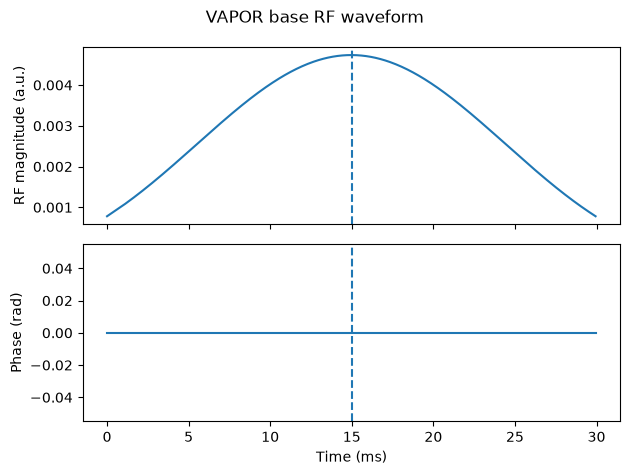

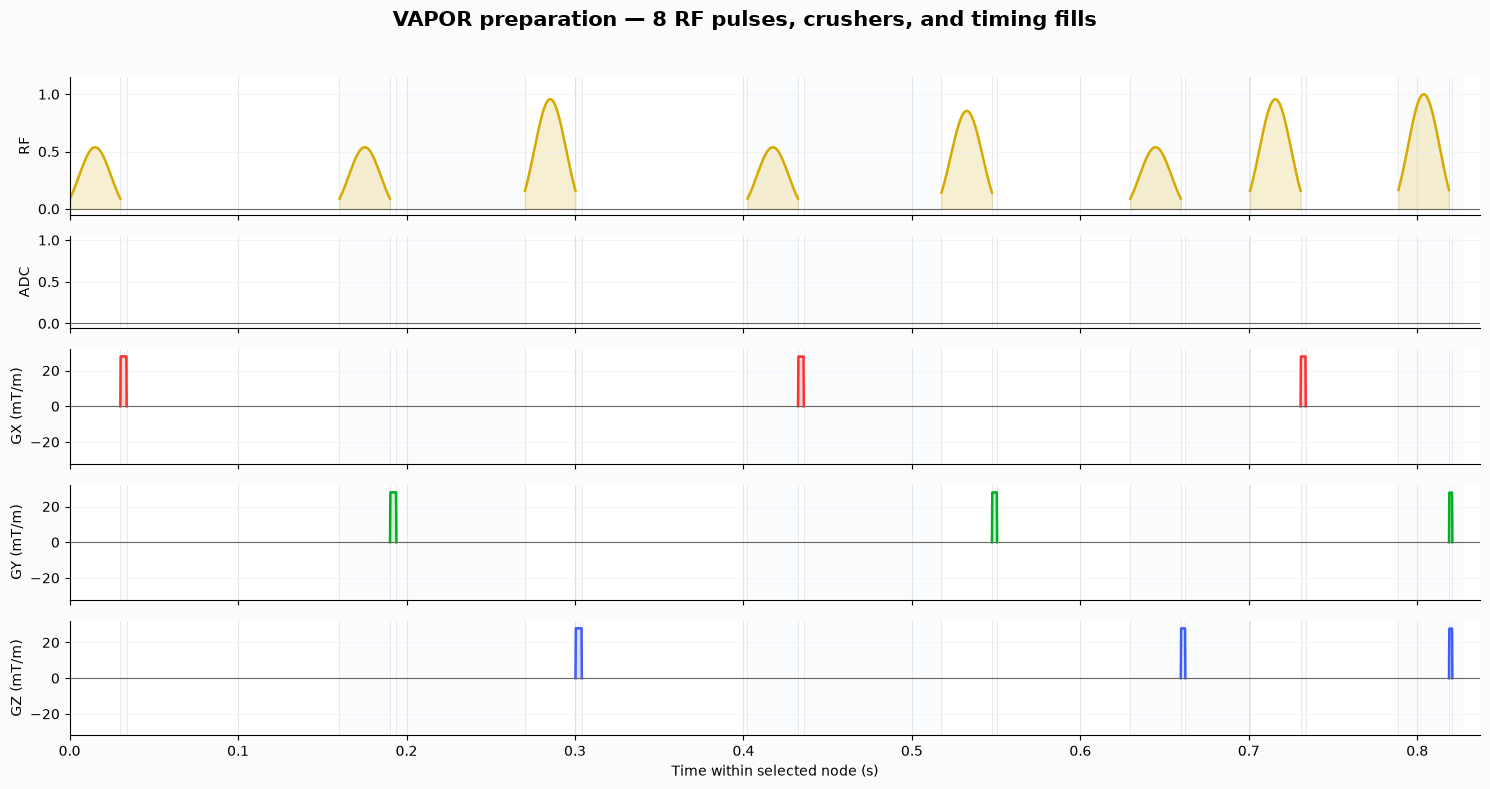

In [10]:
from pypulseq_star.mag_prep.water_suppression import make_vapor

vapor_protocol = demo_PRESS.define_protocol()
vapor_seq = ppstar.Sequence(
    system=system,
    protocol=vapor_protocol,
    name="vapor_walkthrough",
)
vapor_seq.set_encoding_frame("axial")
vapor_seq.set_node("root", role="spectroscopy")

vapor = make_vapor(
    vapor_seq,
    vapor_protocol,
    node="root.vapor",
    display_rf=True,   # first figure: base SLR RF waveform
)

vapor_resolved = vapor_seq.resolve()
ok, report = vapor_resolved.check_timing()

print(f"VAPOR duration: {vapor.duration_s * 1e3:.1f} ms")
print(f"Blocks:         {len(vapor.blocks)}")
print(f"Timing:         {'PASS' if ok else 'FAIL'}")
if report:
    for item in report:
        print("  ", item)

_ = vapor_seq.plot(
    realization=vapor_resolved,
    title="VAPOR preparation — 8 RF pulses, crushers, and timing fills",
    gradient_scale="mt_per_m",
    figsize=(15, 8),
    dpi=130,
)


## 3. Milestone 2 — one PRESS localization/acquisition kernel

The PRESS implementation remains explicit in `demo_PRESS.make_press()`:

- RF1: 90° excitation on logical **slice**
- RF2: 180° refocusing on logical **phase**
- RF3: 180° refocusing on logical **read**
- crushers around RF2/RF3
- spectroscopy ADC
- TE1/TE2 timing fills
- 16-state RF/receiver phase cycle attached to the enclosing average loop

The important PyPulseq-Star idea is that the timing is not hand-filled with fixed delays. The fills are expressions derived from the requested TE1/TE2 and the actual event occupancy.

Here we place just one PRESS motif inside the same kind of repetition node used by the complete sequence and inspect one repetition.


TE1:   32.00 ms
TE2:   65.00 ms
TE:    97.00 ms
Timing: PASS
RF1: requested 3.000 ms | realized 3.000 ms | peak B1 11.015 µT
RF2: requested 5.000 ms | realized 7.530 ms | peak B1 14.993 µT
RF3: requested 5.000 ms | realized 7.530 ms | peak B1 14.993 µT


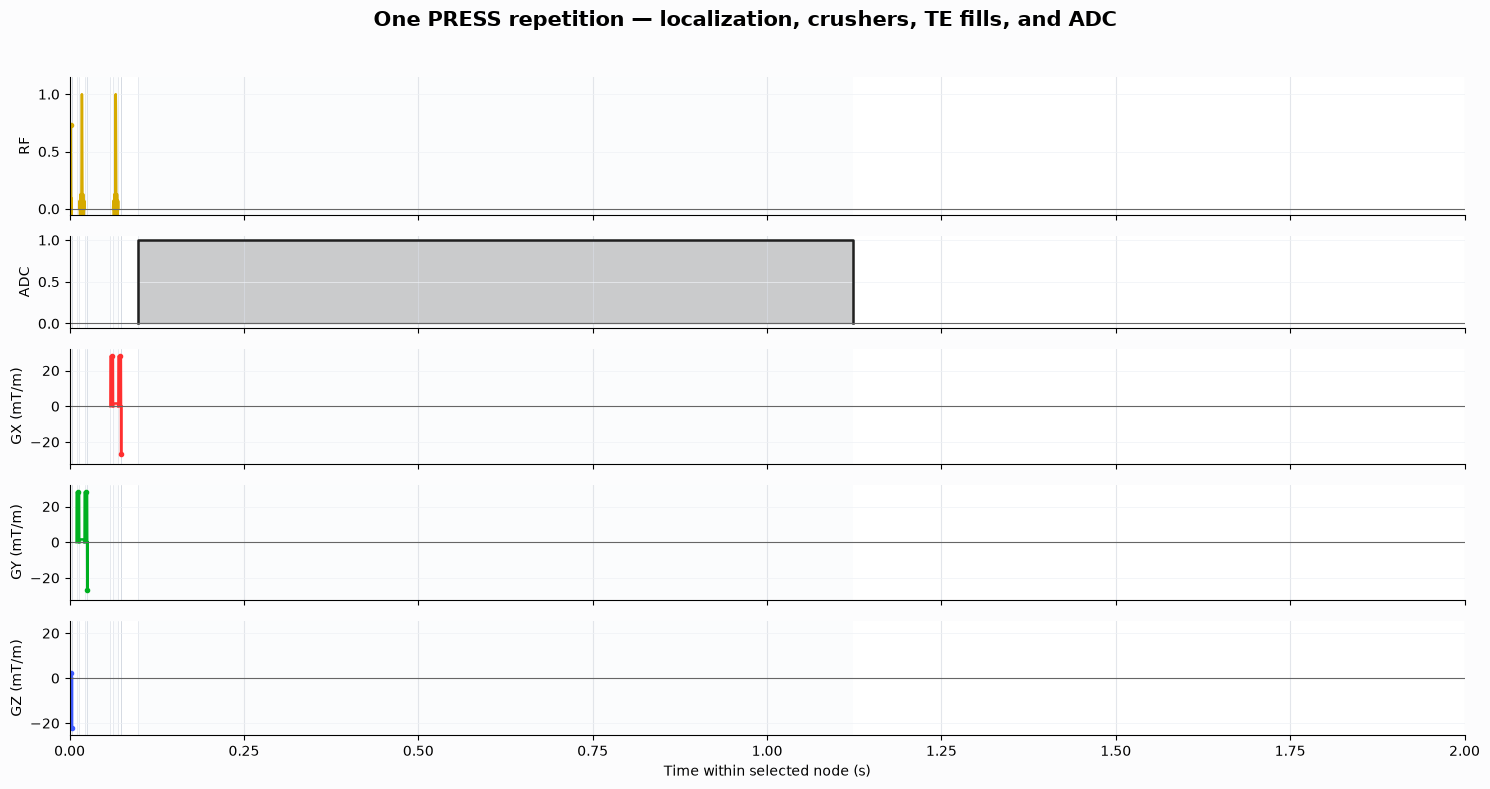

In [12]:
press_protocol = demo_PRESS.define_protocol(
    overrides={
        "spectroscopy_metabolite_nsa": 16,
        "water_reference_enabled": False,
        "spectroscopy_water_suppression_enabled": False,
    }
)

press_seq = ppstar.Sequence(
    system=system,
    protocol=press_protocol,
    name="press_kernel_walkthrough",
)
press_seq.set_encoding_frame(press_protocol.get_parameter("press_orientation"))
press_seq.set_node("root", role="press_spectroscopy")

averages = press_seq.set_node(
    "root.averages",
    role="spectroscopy_averages",
    factor=press_protocol.symbols.spectroscopy_metabolite_nsa,
    repeat_every=press_protocol.symbols.press_repetition_time_s,
    counter="nsa_index",
    repeat_mode="loop",
)

voxel = demo_PRESS.make_press_voxel(press_protocol)
press = demo_PRESS.make_press(
    press_seq,
    press_protocol,
    voxel=voxel,
    node="root.averages.kernel_press",
    repeat_node=averages,
    phase_cycle=demo_PRESS.PRESS_EXORCYCLE_16,
)

press_resolved = press_seq.resolve()
ok, report = press_resolved.check_timing()

print(f"TE1:   {press_resolved.protocol.press_te1_s * 1e3:.2f} ms")
print(f"TE2:   {press_resolved.protocol.press_te2_s * 1e3:.2f} ms")
print(f"TE:    {(press_resolved.protocol.press_te1_s + press_resolved.protocol.press_te2_s) * 1e3:.2f} ms")
print(f"Timing: {'PASS' if ok else 'FAIL'}")

for label, rf in (
    ("RF1", press.excitation[0]),
    ("RF2", press.refocusing_1[0]),
    ("RF3", press.refocusing_2[0]),
):
    p = getattr(rf, "parameters", {})
    print(
        f"{label}: requested {p.get('requested_duration', rf.duration)*1e3:.3f} ms | "
        f"realized {rf.duration*1e3:.3f} ms | "
        f"peak B1 {p.get('realized_peak_b1_t', float('nan'))*1e6:.3f} µT"
    )

_ = press_seq.plot(
    realization=press_resolved,
    one_tr=True,
    title="One PRESS repetition — localization, crushers, TE fills, and ADC",
    gradient_scale="mt_per_m",
    figsize=(15, 8),
    dpi=130,
)


## 4. Milestone 3 — compose the complete experiment

The complete experiment is only a small amount of orchestration because VAPOR and PRESS are already reusable modules.

The hierarchy is:

```text
root
├── metabolite
│   └── averages_metabolite      [NSA loop, period = TR]
│       ├── vapor
│       └── kernel_press
└── water
    └── averages_water           [NSA loop, period = TR]
        └── kernel_press
```

The same `make_press()` implementation is used for metabolite and water-reference acquisitions. VAPOR appears only in the metabolite branch.


Resolved experiment
  TE1:             32.00 ms
  TE2:             65.00 ms
  TR:              2.000 s
  metabolite NSA:  16
  water NSA:       2
  stored blocks:   52
  timing:          PASS


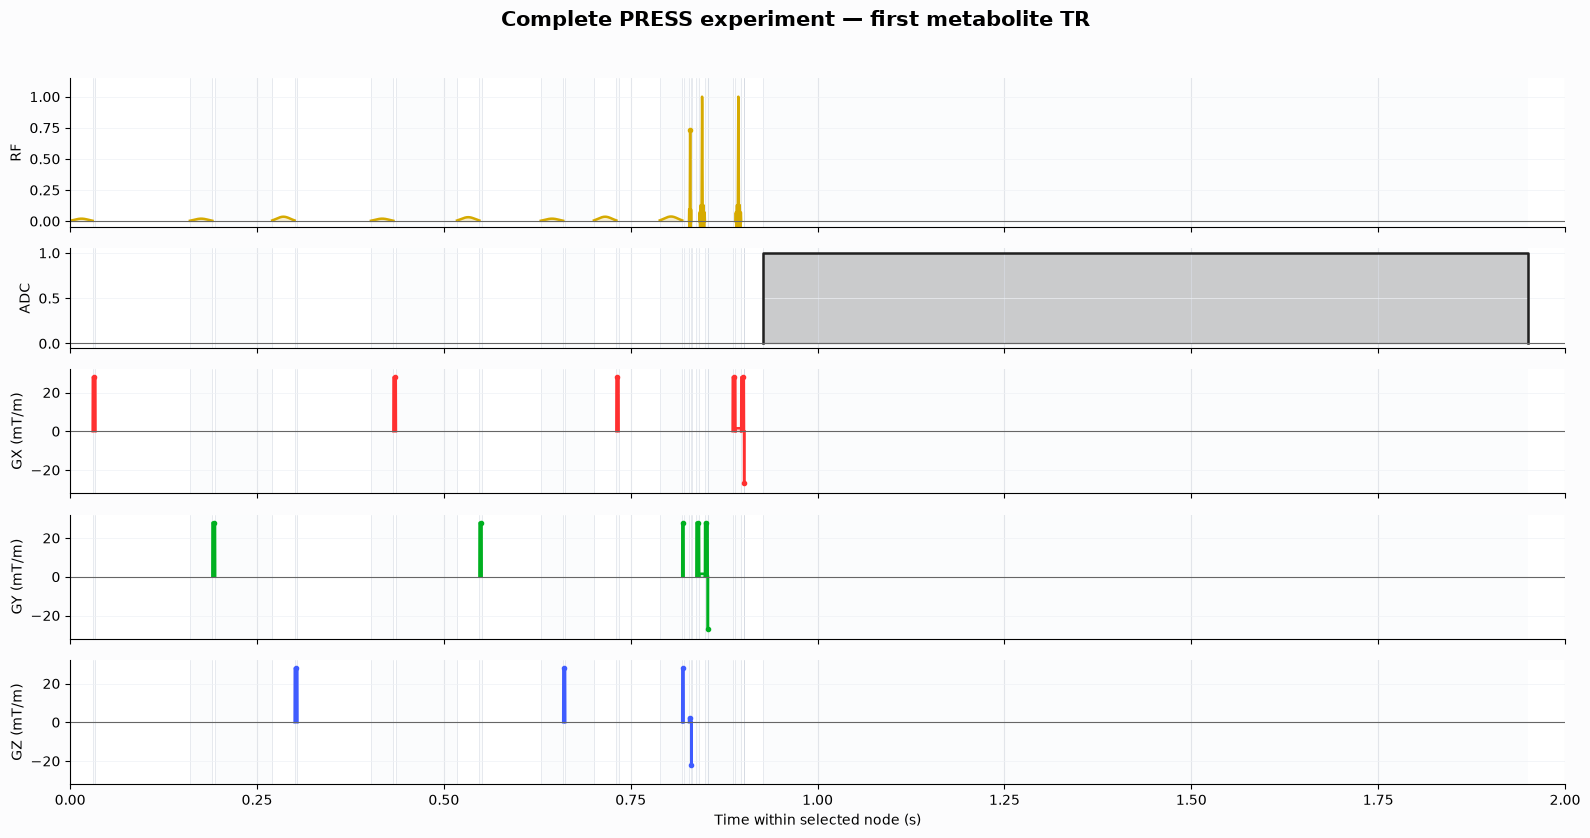

In [14]:
seq = demo_PRESS.build_sequence(system, protocol)
resolved = seq.resolve()

timing_ok, timing_report = resolved.check_timing()
assert timing_ok, "\n".join(str(item) for item in timing_report)

print("Resolved experiment")
print(f"  TE1:             {resolved.protocol.press_te1_s * 1e3:.2f} ms")
print(f"  TE2:             {resolved.protocol.press_te2_s * 1e3:.2f} ms")
print(f"  TR:              {resolved.protocol.press_repetition_time_s:.3f} s")
print(f"  metabolite NSA:  {resolved.protocol.spectroscopy_metabolite_nsa}")
print(f"  water NSA:       {resolved.protocol.water_reference_nsa}")
print(f"  stored blocks:   {len(resolved.sequence.timeline.blocks)}")
print("  timing:          PASS")

_ = seq.plot(
    realization=resolved,
    one_tr=True,
    title="Complete PRESS experiment — first metabolite TR",
    gradient_scale="mt_per_m",
    figsize=(16, 8.5),
    dpi=130,
)


## 5. Export the same source to Pulseq and gammaSTAR

The source sequence does not need to be rewritten for each backend.

- Pulseq receives the resolved numerical realization.
- gammaSTAR receives the relationship-aware document with validated defaults.

This is the practical reason to keep the protocol, relationships, hierarchy, and scanner realization separate.


In [19]:
from pypulseq_star.writers import GammaStarWriter, PulseqWriter

out = repo / "out" / "notebook_press"
out.mkdir(parents=True, exist_ok=True)

seq_path = PulseqWriter(seq).write(
    out / "press_axial.seq",
    realization=resolved,
)
json_path = GammaStarWriter(seq).write(
    out / "press_axial.seq.json",
    defaults=resolved,
)

print("Export complete")
print(f"  Pulseq:    {seq_path}")
print(f"  gammaSTAR: {json_path}")


Export complete
  Pulseq:    /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/out/notebook_press/press_axial.seq
  gammaSTAR: /Users/sairamgeethanath/Documents/Contributions/Tools/Projects/OSPS/pypulseq-star-clean/out/notebook_press/press_axial.seq.json


## 6. Edit the protocol and rebuild — without rewriting PRESS

This final helper is the part to experiment with.

It takes only an `overrides` dictionary, then repeats the same sequence pipeline:

```text
define protocol → build → resolve → validate → plot
```

Try changing the scientific prescription rather than touching event-level code. PyPulseq-Star recomputes the dependent timing and scanner realization.


In [20]:
def try_press(overrides: dict[str, object], *, plot: bool = True):
    """Rebuild the complete experiment from a small protocol edit."""
    edited_protocol = demo_PRESS.define_protocol(overrides=overrides)
    edited_system = demo_PRESS.define_system()

    edited_seq = demo_PRESS.build_sequence(edited_system, edited_protocol)
    edited = edited_seq.resolve()
    ok, report = edited.check_timing()

    print(f"Timing: {'PASS' if ok else 'FAIL'}")
    print(
        f"TE1/TE2/TE = "
        f"{edited.protocol.press_te1_s*1e3:.1f} / "
        f"{edited.protocol.press_te2_s*1e3:.1f} / "
        f"{(edited.protocol.press_te1_s + edited.protocol.press_te2_s)*1e3:.1f} ms"
    )
    print(f"TR = {edited.protocol.press_repetition_time_s:.3f} s")
    print(
        "Voxel = "
        f"{edited.protocol.press_voxel_size_read_m*1e3:.0f} × "
        f"{edited.protocol.press_voxel_size_phase_m*1e3:.0f} × "
        f"{edited.protocol.press_voxel_size_slice_m*1e3:.0f} mm³"
    )
    print(
        f"NSA = {edited.protocol.spectroscopy_metabolite_nsa} metabolite + "
        f"{edited.protocol.water_reference_nsa} water"
    )

    if report:
        for item in report:
            print("  ", item)

    if ok and plot:
        edited_seq.plot(
            realization=edited,
            one_tr=True,
            title="Edited PRESS protocol — relationships recomputed automatically",
            gradient_scale="mt_per_m",
            figsize=(16, 8.5),
            dpi=130,
        )

    return edited_seq, edited


### Georg / Peter sandbox

Edit only the values that are interesting, then rerun this one cell.

Useful experiments:

- change **TE1 / TE2** and watch the timing fills move;
- change the **voxel dimensions** and inspect selective gradients;
- move the voxel off isocenter and inspect RF frequency offsets;
- change **TR** or **NSA** without touching the PRESS kernel;
- switch **axial / coronal / sagittal** and inspect the logical-to-physical gradient mapping;
- turn water suppression or the water reference on/off;
- change the scanner `max_rf` in `define_system()` to inspect hardware-driven RF realization.

The sequence code remains the same because these are protocol or scanner changes, not new sequence implementations.


Timing: PASS
TE1/TE2/TE = 32.0 / 65.0 / 97.0 ms
TR = 2.000 s
Voxel = 20 × 20 × 20 mm³
NSA = 16 metabolite + 2 water


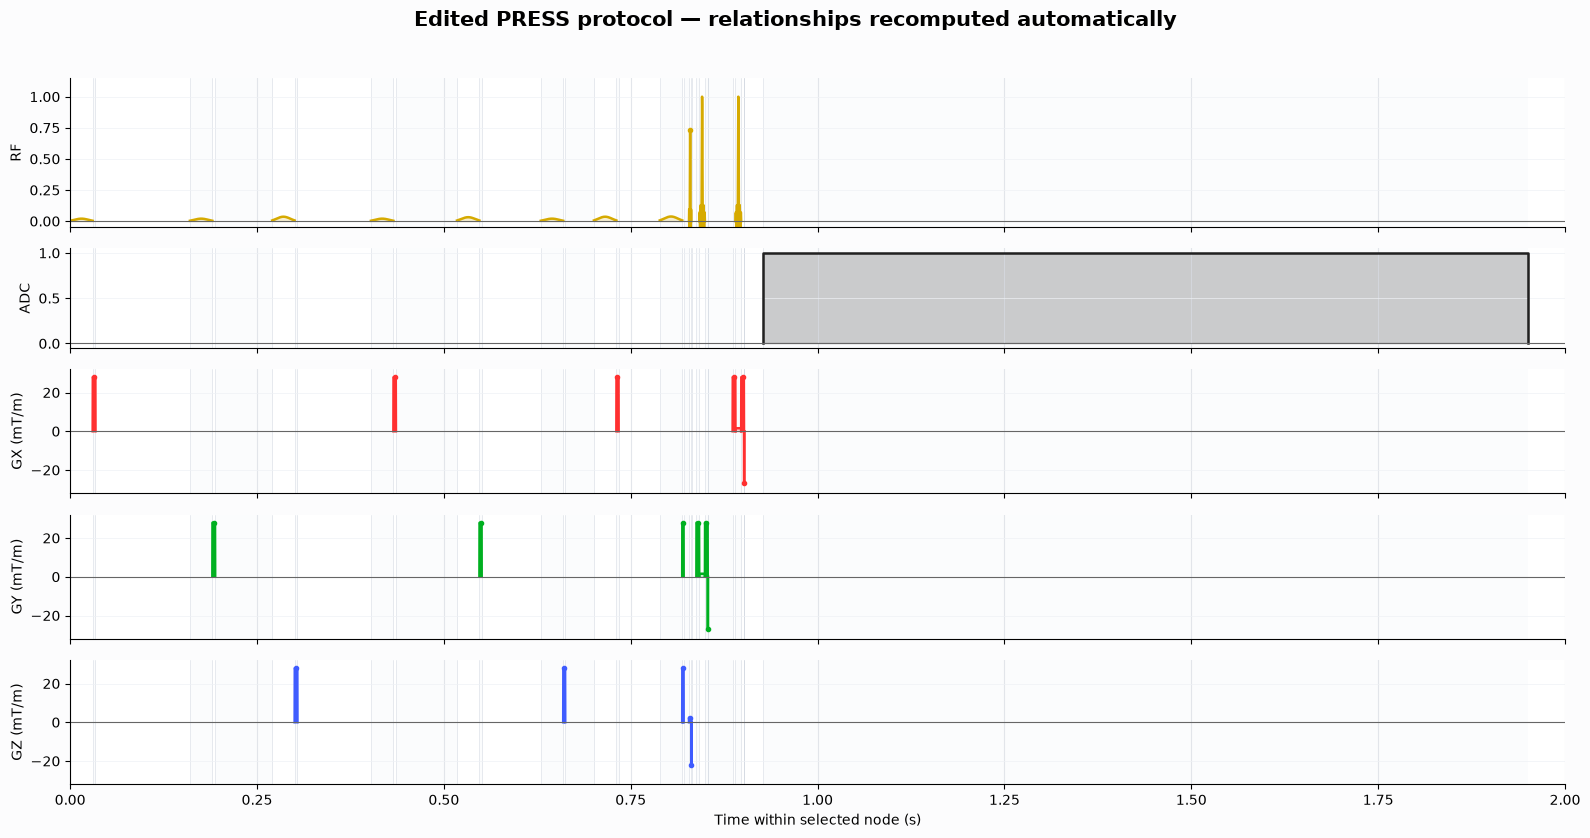

In [21]:
experiment = {
    # PRESS timing
    "press_te1_s": 32e-3,
    "press_te2_s": 65e-3,
    "press_repetition_time_s": 2.0,

    # Voxel geometry
    "press_orientation": "axial",
    "press_voxel_size_read_m": 20e-3,
    "press_voxel_size_phase_m": 20e-3,
    "press_voxel_size_slice_m": 20e-3,
    "press_voxel_position_read_m": 0.0,
    "press_voxel_position_phase_m": 0.0,
    "press_voxel_position_slice_m": 0.0,

    # Acquisition
    "spectroscopy_metabolite_nsa": 16,
    "water_reference_nsa": 2,
    "spectroscopy_num_samples": 2048,
    "spectroscopy_dwell_s": 500e-6,

    # Carrier and acquisition families
    "press_transmit_frequency_offset_hz": 0.0,
    "spectroscopy_water_suppression_enabled": True,
    "water_reference_enabled": True,
}

edited_seq, edited_resolved = try_press(experiment)


## What to look at next

Once the coding pattern is comfortable, the most useful next questions are scientific rather than syntactic:

- which PRESS RF designs should replace or complement the current sinc localization pulses - external sta files can be read later - implementation allows but not implemented;
- how RF bandwidth/B1 constraints should be represented across scanners;
- how crusher prescriptions should be parameterized;
- which quantities should remain editable after gammaSTAR export;
- and which spectroscopy invariants should be explicitly encoded as relationships or validation constraints.

That is the intended role of PyPulseq-Star: keep the **experiment** explicit while letting scanner-specific realization happen underneath it.
